In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append(".")
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from matplotlib import pyplot as plt

from vascx.utils.fundus import FundusPreprocessor
from vascx import preprocess, Retina
from vascx.features import Tortuosity, TortuosityMeasure, Caliber, Length, Zone
from utils import get_examples_dict

In [3]:
data_path = "/mnt/ssd1/jose/sinergia/ageset/v3/"

In [4]:
examples_dict = get_examples_dict(data_path)
examples = examples_dict.values()

def make_retina(ex):
    r = Retina.from_file(ex[1], scaling_factor=ex[0])
    r.load_disc(ex[2])
    r.load_fundus_image(ex[3])
    return r


def get_next_retina():
    ex = next(examples)
    return make_retina(ex)


def get_imageid(id):
    ex = examples_dict[id]
    return make_retina(ex)

In [5]:
tort = Tortuosity(TortuosityMeasure.Curvature, Zone.All)

### Interesting examples
Low tortuosity
- 193131
- 196175

Medium tortuosity
- 194084
- 199273
- 199695

High tortuosity
- 195413

Localized tortuosity
- 196589

Tortuosity of small vessels
- 197241
- 199656

Differences in arteries vs veins
- 198215
- 200318
- 201443
- 204524
- 204768
- 205110

Tortuosity near macula
- 205101: high tortuosity near macula
- 212087: light
- 214635

In [6]:
ret = get_imageid(194084)

In [7]:
# ret.plot_fundus()

In [8]:
# ret.plot_fundus()

In [9]:
# tort.compute(ret.arteries)

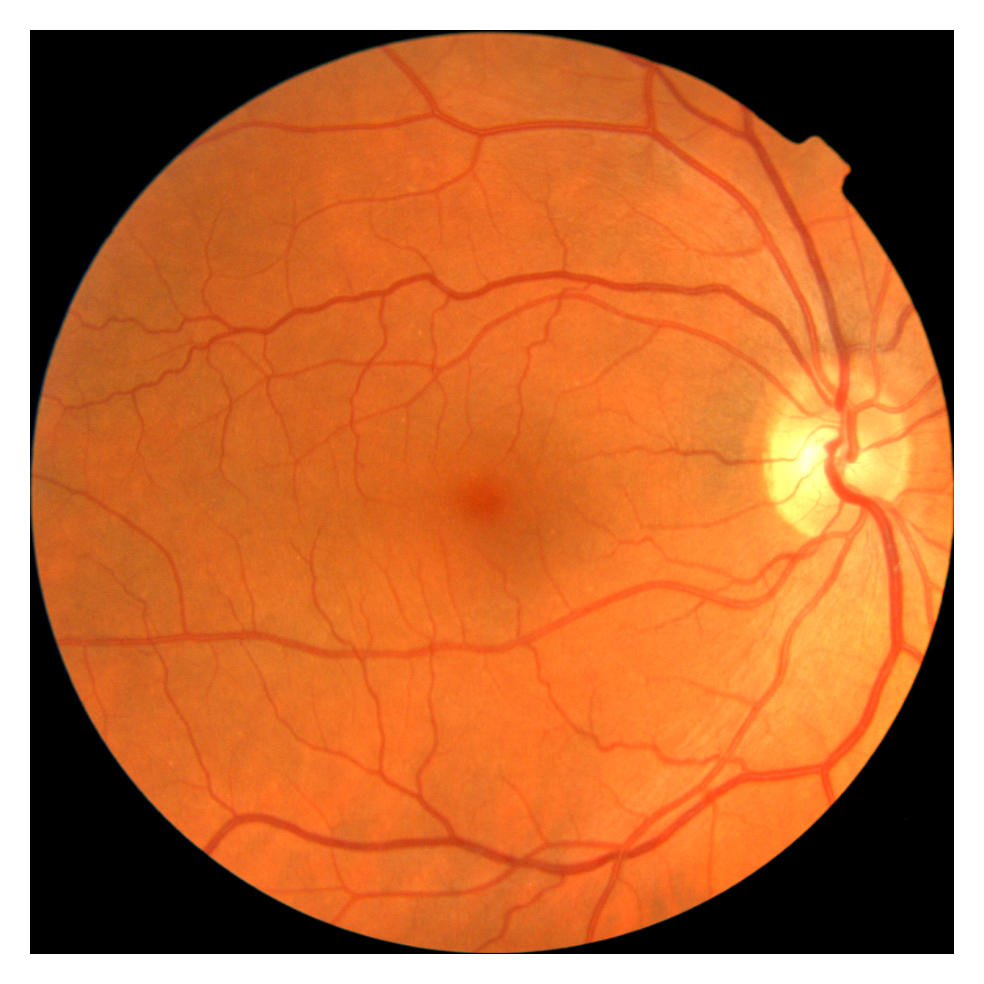

In [10]:
ret.plot_fundus()

In [11]:
ret.variance_of_laplacian()

58.03343968245363

In [12]:
tort.compute(ret.arteries)

0.008539028515512706

In [13]:
tort.compute(ret.veins)

0.017510163776451267

<__array_function__ internals>:200: RuntimeWarning: invalid value encountered in cast


(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

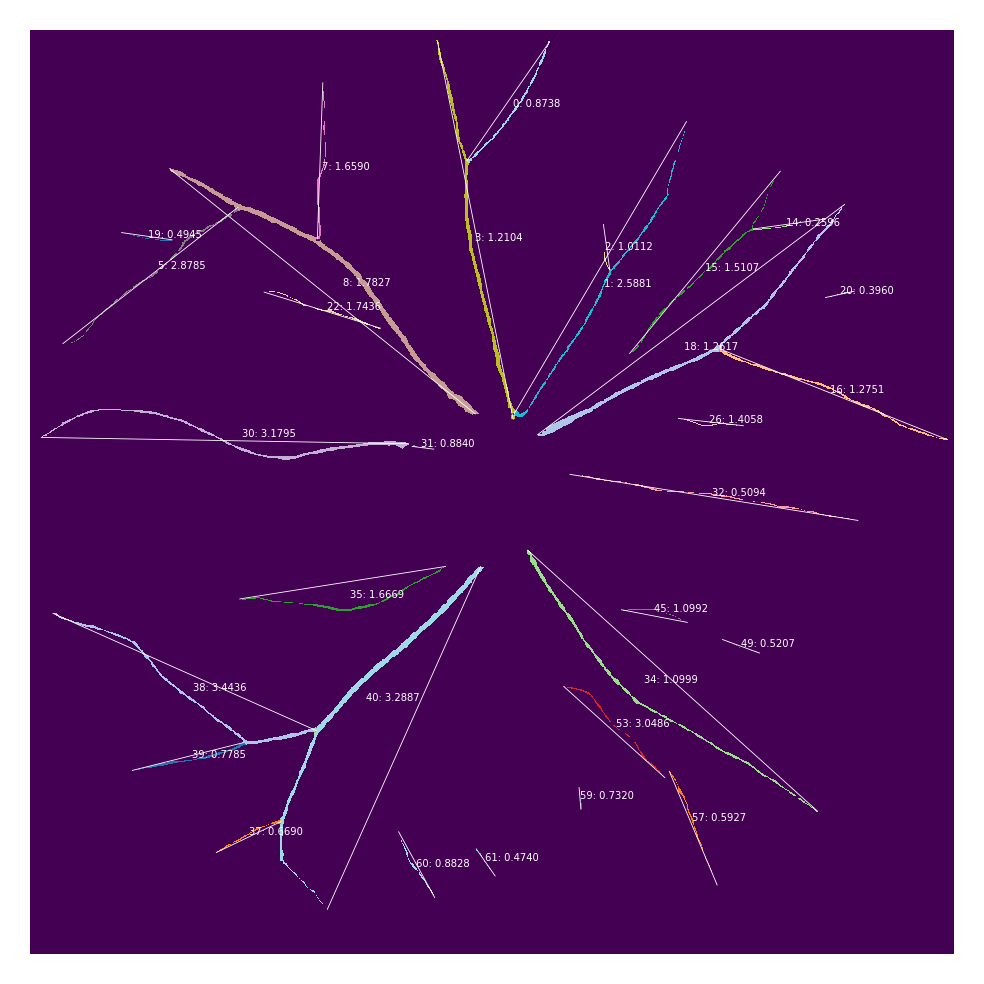

In [14]:
tort.plot(ret.arteries, plot_endpoints=False, min_numpoints=25)

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

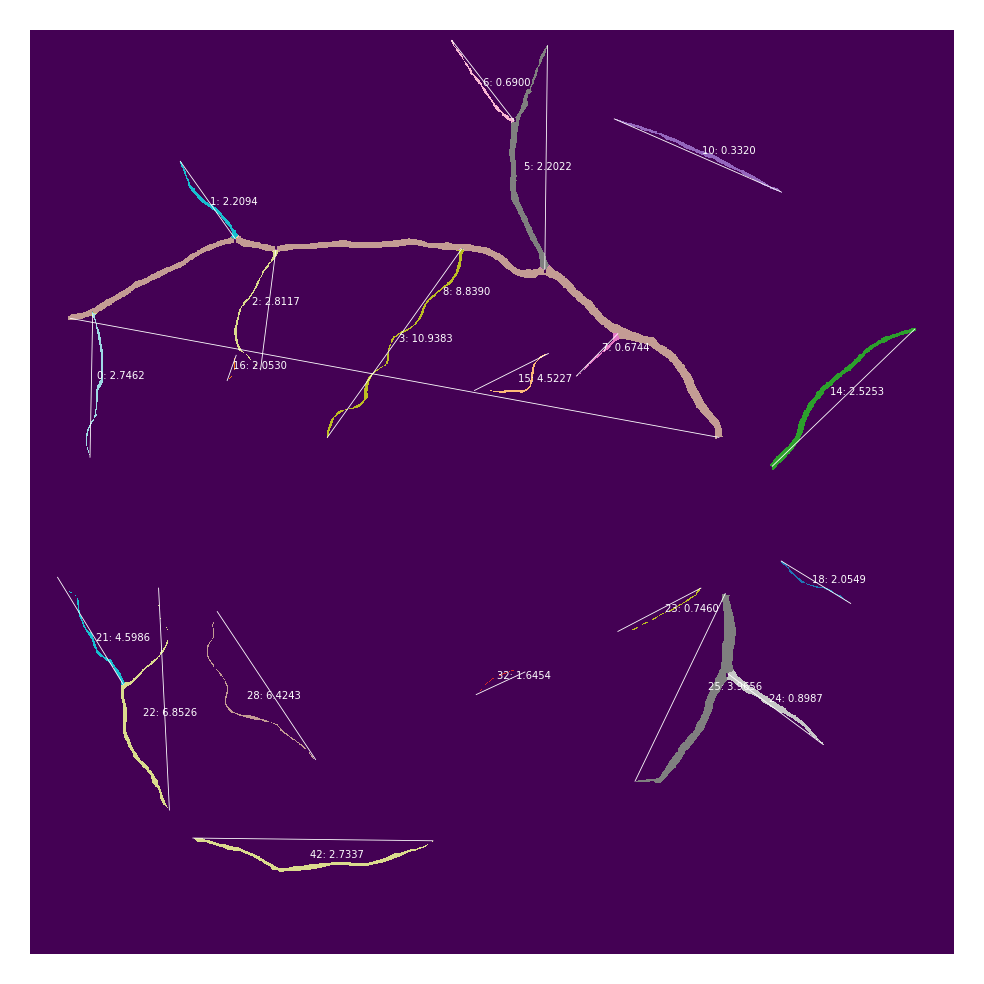

In [33]:
tort.plot(ret.veins, plot_endpoints=False, min_numpoints=25)

In [13]:
from vascx.segment import SplineInterpolation
spline = SplineInterpolation(seg, 0.25)

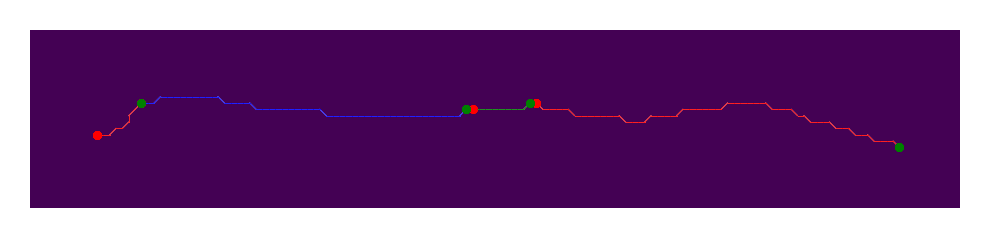

In [14]:
seg.plot_skeleton()

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

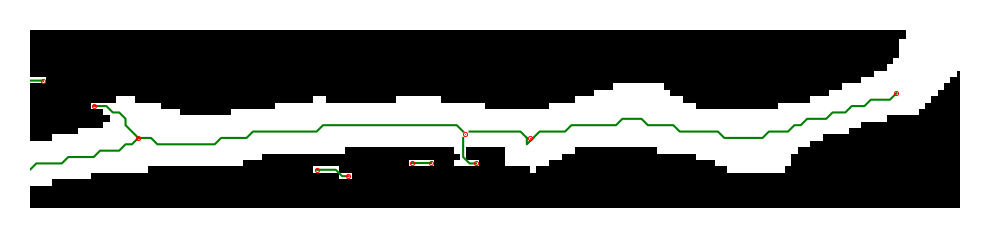

In [13]:
seg.plot_graph()

In [14]:
len(seg.original_segments)

4

In [22]:
seg.original_segments[0].id

frozenset({41, 44})

In [12]:
seg.original_segments[1].id

frozenset({40, 41})

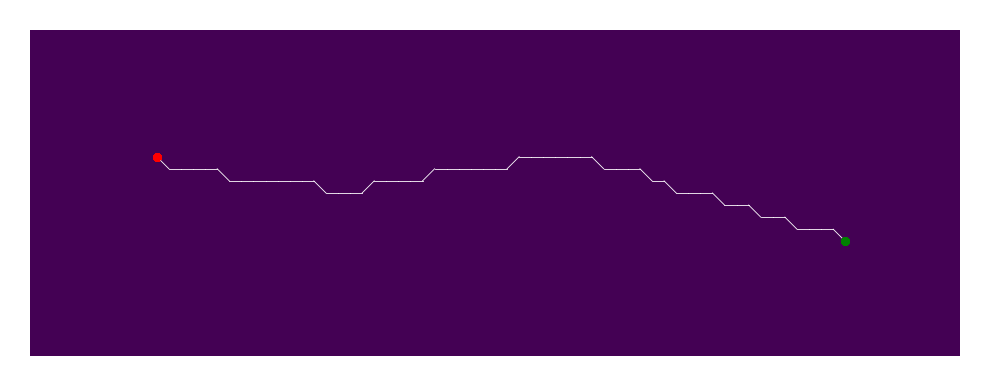

In [15]:
seg.original_segments[0].plot_skeleton()

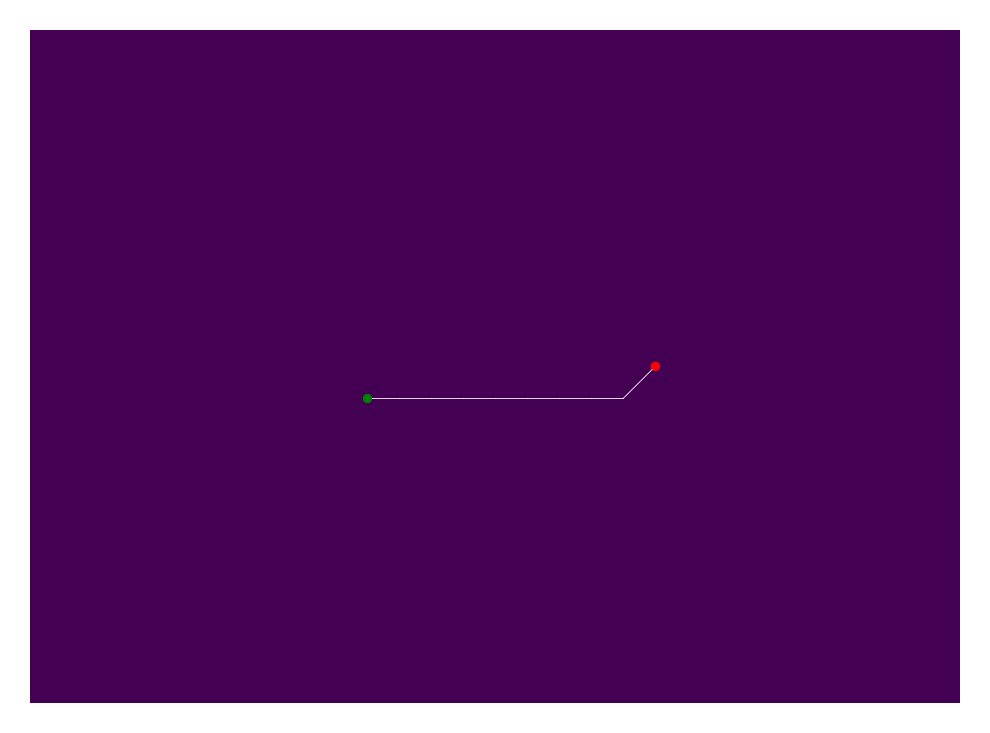

In [16]:
seg.original_segments[1].plot_skeleton()

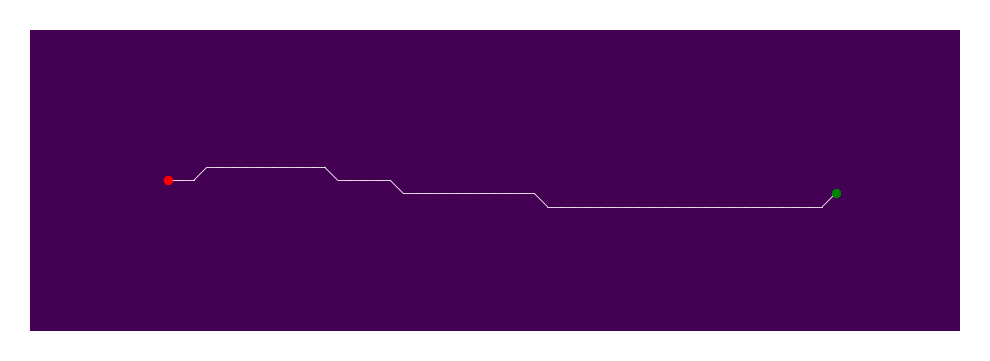

In [17]:
seg.original_segments[2].plot_skeleton()

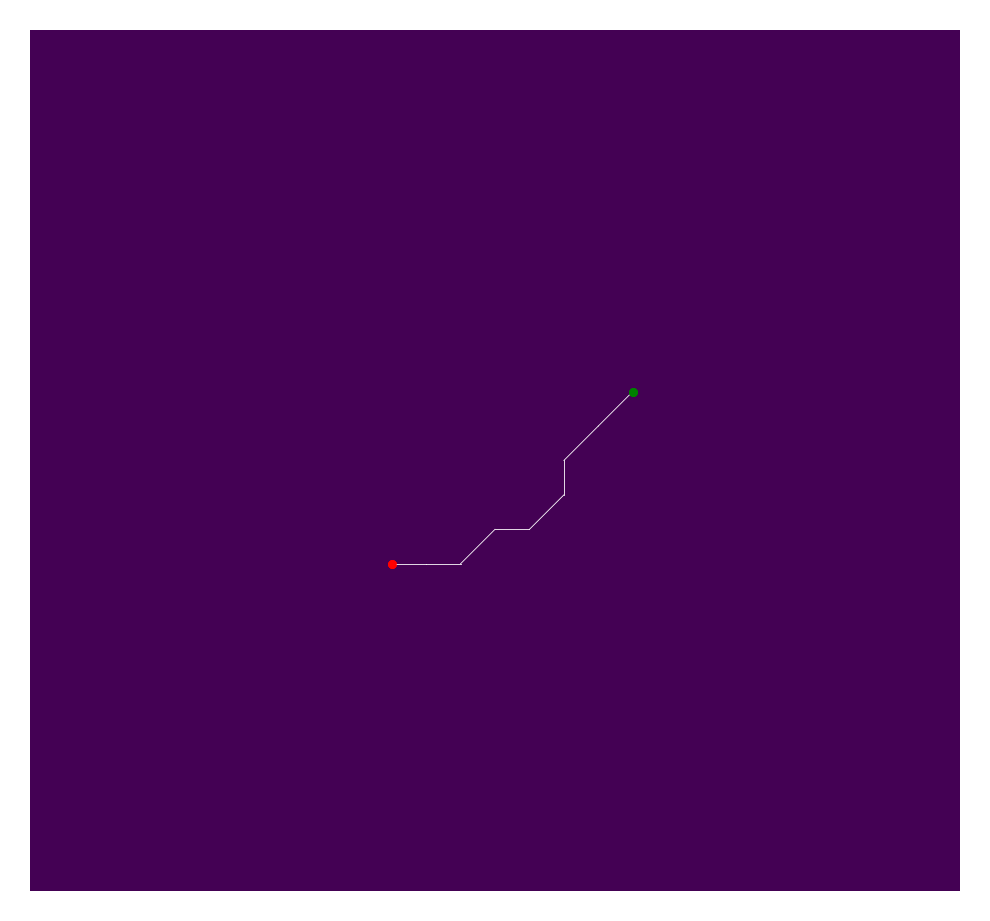

In [18]:
seg.original_segments[3].plot_skeleton()

In [19]:
curvatures = spline.curvatures()

In [20]:
curvatures

[0.015101934422596107,
 0.020605555281795772,
 0.027264955880294883,
 0.030034923622816304,
 0.018815961837980292,
 0.00773045114500942,
 0.003326306675000005,
 0.006185240861862274,
 0.004709514475806743,
 0.002973918561318979,
 0.0013685118528688185,
 0.0004275232475890195,
 0.00016568453511845276,
 0.002762245738325171,
 1416.1770869597508,
 0.017869509321924736,
 1.6858724976856954,
 0.009585711586890585,
 0.0025811264013430838,
 0.002108128281043335,
 0.003631828248995727,
 0.00614761874626992,
 0.00890001196993781,
 0.010821968079577176,
 0.011083481380258773,
 0.001011727304372159,
 0.012804899398747042,
 0.027499784281207446,
 0.047096679880963756,
 0.06699618821101258,
 0.07081071590663547]

<__array_function__ internals>:200: RuntimeWarning: invalid value encountered in cast


(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

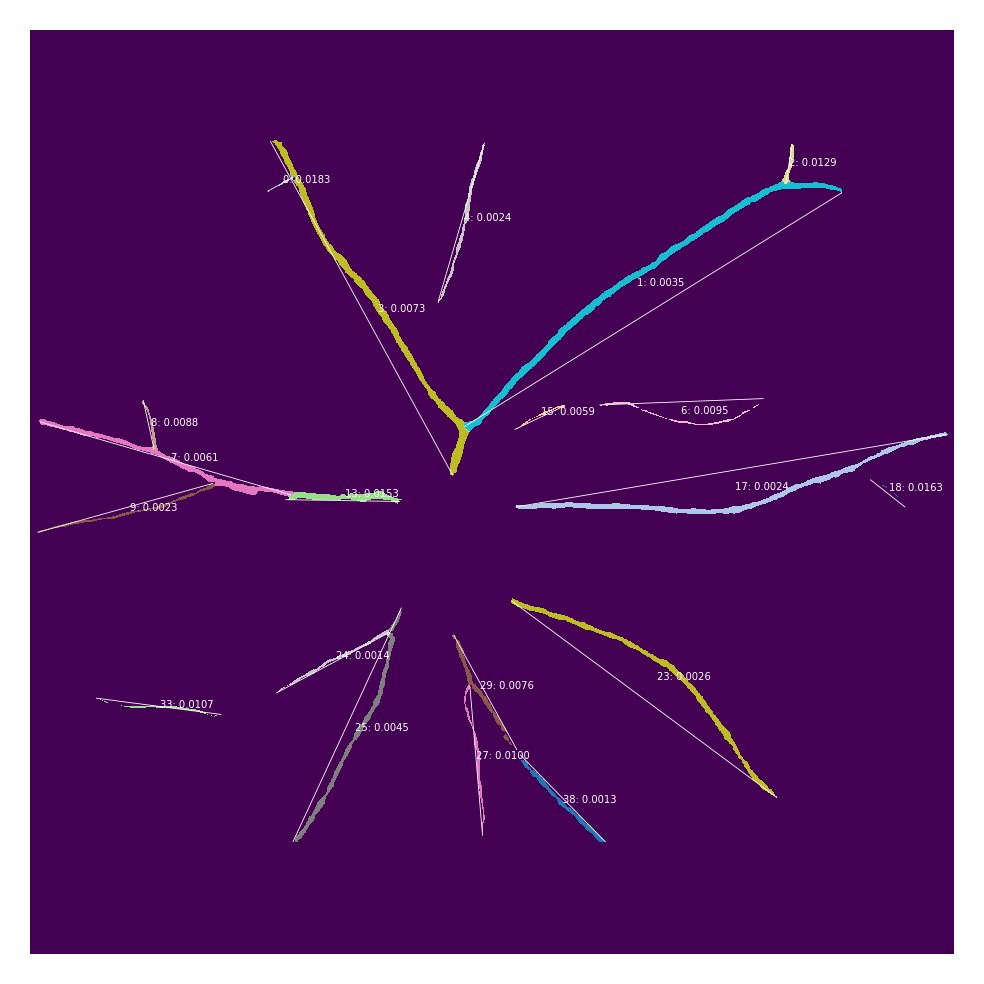

In [33]:
tort.compute(ret.veins)

0.0223978777324878

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

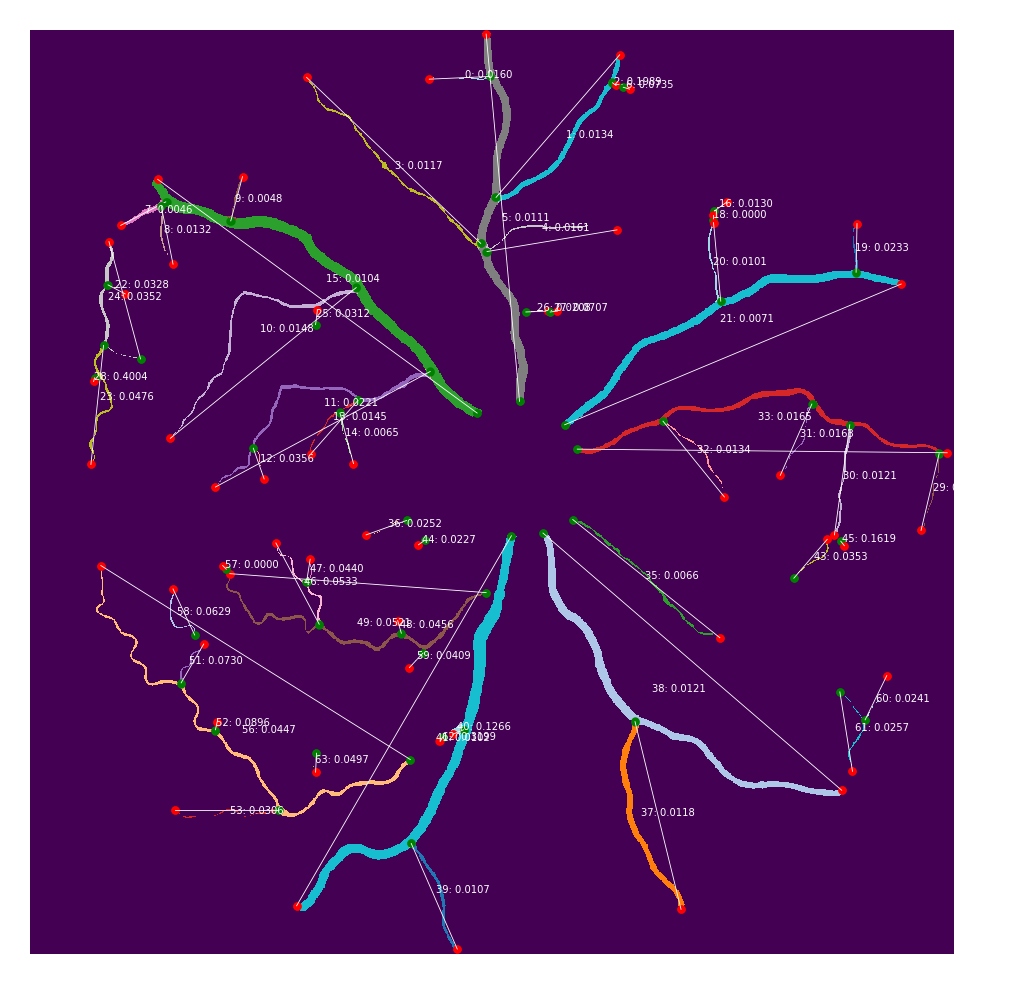

In [34]:
tort.plot(ret.veins)